# MNIST 손글씨 분류 — MLP (PyTorch)

PyTorch 로 **다층 퍼셉트론(MLP)** 을 구성해 MNIST 숫자를 분류합니다. 이전 SLP 대비 은닉층을 추가해 비선형 표현력을 확보하면 정확도가 어떻게 향상되는지 비교합니다.

## 학습 목표
- `nn.Module` 로 여러 `nn.Linear` 층을 쌓아 MLP 를 정의한다.
- 활성화 함수(ReLU)와 손실(`nn.CrossEntropyLoss`)의 역할을 이해한다.
- 학습 루프(forward → loss → backward → step)와 평가 루프를 직접 작성한다.
- `torch.save` / `load` 로 모델을 저장·복원한다.

## 사용 라이브러리
- `torch`, `torch.nn`, `torch.optim` — 모델 정의·학습
- `torchvision.datasets`, `torchvision.transforms`, `DataLoader` — MNIST 로드 및 배치
- `numpy`, `matplotlib` — 데이터/예측 시각화


In [1]:
# 필기체 숫자 MNIST MLP 모델 (PyTorch)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print(f'PyTorch version: {torch.__version__}')

# 디바이스 설정 (RTX 4060 등 GPU 가용 시 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

# 데이터 변환: PIL → Tensor (0~1 자동 정규화)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# MNIST 다운로드 및 로드
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

print(f'\ntrain_dataset: {len(train_dataset)}개, image shape={train_dataset[0][0].shape}, dtype={train_dataset[0][0].dtype}')
print(f'test_dataset:  {len(test_dataset)}개')


PyTorch version: 2.6.0+cu124
사용 디바이스: cuda

train_dataset: 60000개, image shape=torch.Size([1, 28, 28]), dtype=torch.float32
test_dataset:  10000개


## 데이터 미리보기

학습 데이터에서 36개 샘플을 그리드 형태로 확인합니다. MNIST는 손글씨 숫자(0~9)로 구성된 균형 잡힌 데이터셋입니다.

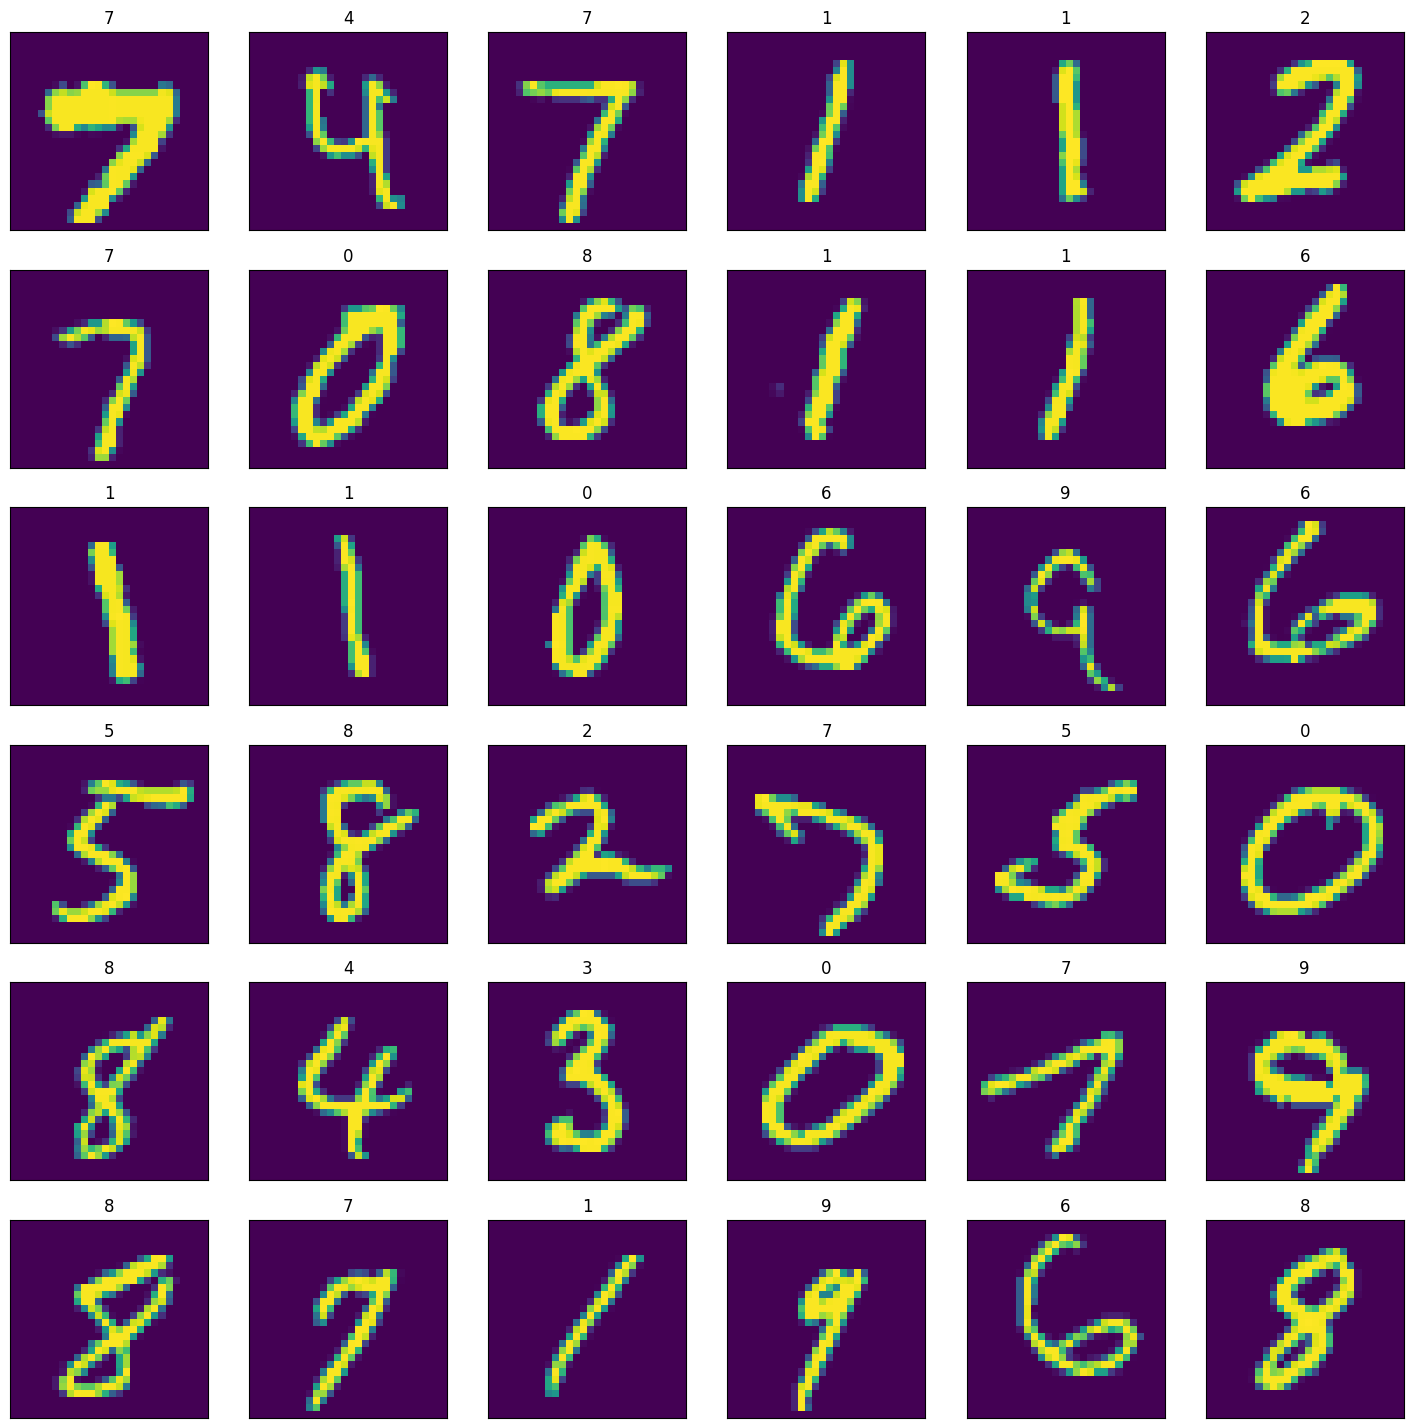

In [2]:
# MNIST 보기
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 18))
for idx in range(36):
    id = np.random.randint(len(train_dataset))
    image, label = train_dataset[id]
    number = fig.add_subplot(6, 6, idx+1, xticks=[], yticks=[])
    number.imshow(image.squeeze().numpy())  # (1, 28, 28) → (28, 28)
    number.set_title(class_names[label])


## 픽셀 단위 시각화

이미지 한 장을 28×28 그리드 위에 픽셀 값과 함께 표시해 신경망이 입력으로 받는 실제 수치를 직관적으로 확인합니다.

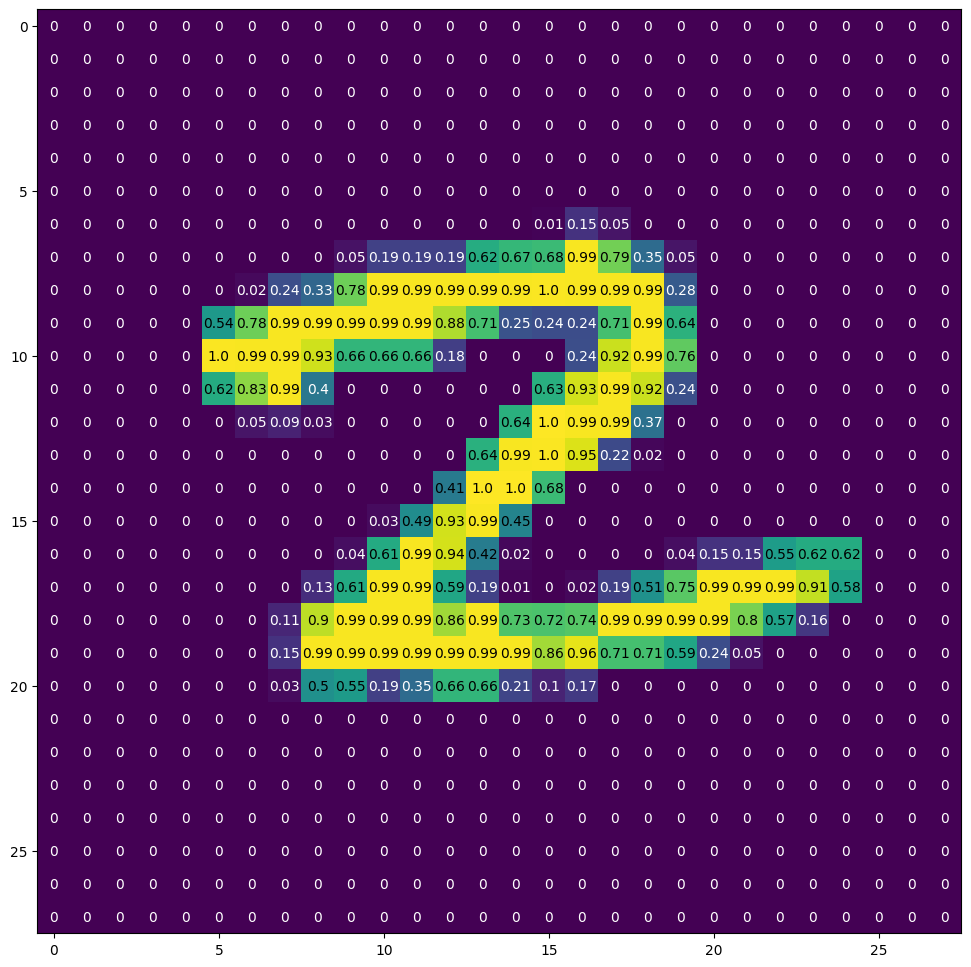

In [3]:
# 이미지 데이터 상세
image, _ = train_dataset[143]
img = image.squeeze().numpy()  # (28, 28)

fig = plt.figure(figsize=(12, 12))
big_number = fig.add_subplot(111)
big_number.imshow(img)
width, height = img.shape
thresh = img.max() / 2.5
for x in range(width):
    for y in range(height):
        val = round(float(img[x][y]), 2) if img[x][y] != 0 else 0
        big_number.annotate(str(val), xy=(y, x),
                            horizontalalignment='center',
                            verticalalignment='center',
                            color='white' if img[x][y] < thresh else 'black')


## MLP 모델 설계

이전 차시의 SLP 는 `nn.Linear(784, 10)` 한 층뿐이었습니다. **MLP(다층 퍼셉트론)** 는 그 사이에 비선형 활성화(ReLU)를 가진 은닉층을 쌓아 표현력을 크게 끌어올립니다.

| 레이어 | 출력 크기 | 비고 |
| --- | --- | --- |
| `nn.Flatten` | 784 | 28×28 → 1D |
| `nn.Linear` + ReLU | 400 | 첫 번째 은닉층 |
| `nn.Linear` + ReLU | 100 | 두 번째 은닉층 |
| `nn.Linear` (logits) | 10 | 클래스 점수 |

총 파라미터 약 35만 개로 SLP(7,850개) 보다 50배 많지만, 정확도는 60%대 → 98%대로 비약적으로 상승합니다.

> PyTorch 의 `nn.CrossEntropyLoss` 는 내부에 `log_softmax + NLL` 이 함께 들어 있어, **모델 출력층에는 Softmax 를 두지 않고 logits 그대로 반환**하는 것이 표준 패턴입니다.


In [4]:
# MLP 모델 설계하기
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 400)
        self.fc2 = nn.Linear(400, 100)
        self.fc3 = nn.Linear(100, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)            # logits 반환 (CrossEntropyLoss 가 softmax 처리)
        return x

model = MLP().to(device)

# 모델 프로파일
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\n총 파라미터 수: {total_params:,}')

# 학습 기준 확정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

총 파라미터 수: 355,110


## 모델 학습

PyTorch 에서는 학습 루프를 **직접** 작성합니다 (`forward → loss → backward → step`). 자유도가 높은 대신 빠뜨리기 쉬운 단계가 있으니 한 번 익혀 두면 다양한 모델에 그대로 적용할 수 있습니다.

| 파라미터 | 값 |
| --- | --- |
| `epochs` | 5 |
| `batch_size` | 128 |
| 옵티마이저 | `Adam(lr=0.001)` |
| 손실 | `nn.CrossEntropyLoss` |


In [5]:
# 학습 반복회수 설정
epochs = 5
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# 학습 루프
for epoch in range(1, epochs + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        correct += (output.argmax(1) == target).sum().item()
        total += target.size(0)

    print(f'Epoch {epoch}/{epochs} - loss: {running_loss/total:.4f} - acc: {correct/total*100:.2f}%')


Epoch 1/5 - loss: 0.3347 - acc: 90.57%
Epoch 2/5 - loss: 0.1253 - acc: 96.26%
Epoch 3/5 - loss: 0.0792 - acc: 97.58%
Epoch 4/5 - loss: 0.0567 - acc: 98.24%
Epoch 5/5 - loss: 0.0408 - acc: 98.77%


## 학습모델 검증

홀드아웃 테스트셋으로 일반화 성능을 측정합니다. 학습 정확도와 차이가 크면 과적합을, 둘 다 낮으면 과소적합을 의심해야 합니다.

In [6]:
# 학습모델 검증하기
model.eval()
test_loss, correct, total = 0.0, 0, 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item() * data.size(0)
        correct += (output.argmax(1) == target).sum().item()
        total += target.size(0)

print(f'Test loss: {test_loss/total:.4f} / Test accuracy: {correct/total*100:.2f}%')


Test loss: 0.0660 / Test accuracy: 97.99%


## 예측 결과 시각화

테스트 셋에서 36개 샘플을 무작위로 뽑아 예측값과 정답을 비교합니다. SLP 대비 MLP는 더 많은 패턴을 학습할 수 있어 오류가 크게 줄어듭니다.

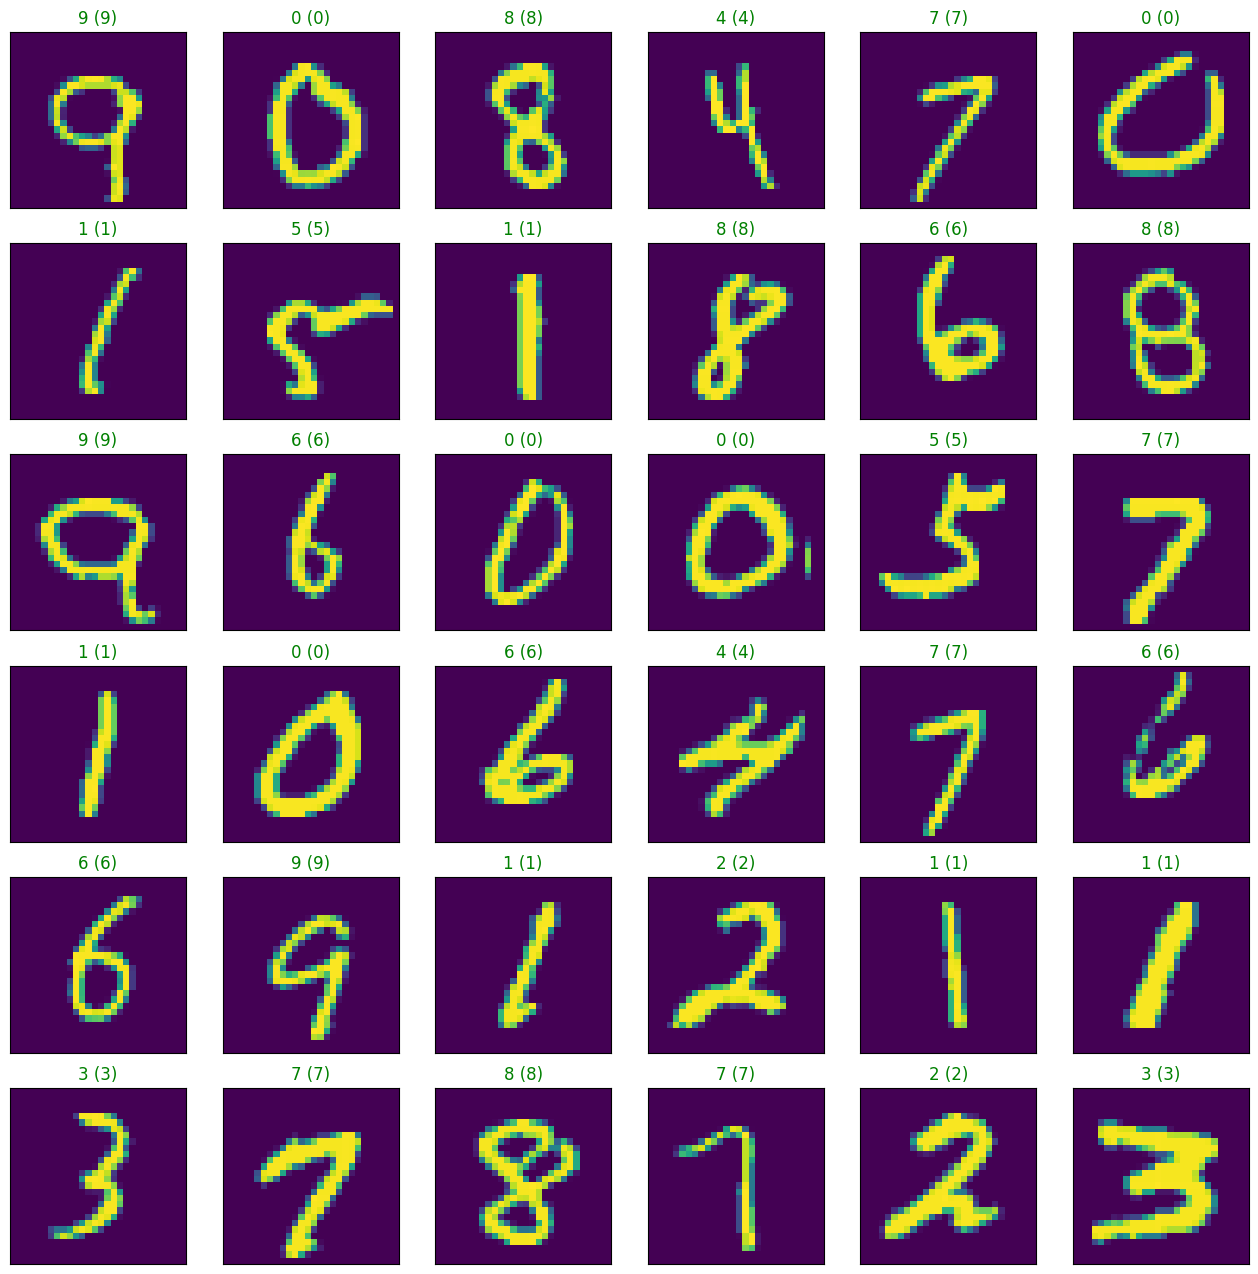

In [7]:
# 예측 결과 확인해 보기
model.eval()
fig = plt.figure(figsize=(16, 16))
with torch.no_grad():
    for idx in np.arange(36):
        id = np.random.randint(len(test_dataset))
        image, label = test_dataset[id]
        x = image.unsqueeze(0).to(device)            # (1, 1, 28, 28)
        pred = int(model(x).argmax(1).item())
        ax = fig.add_subplot(6, 6, idx+1, xticks=[], yticks=[])
        ax.imshow(image.squeeze().numpy())
        ax.set_title(f'{class_names[pred]} ({class_names[label]})',
                     color='green' if pred == label else 'red')


## 모델 저장 (PyTorch)

PyTorch 의 표준 저장 방식은 두 가지입니다.

| 방식 | 저장 대상 | 장점 | 단점 |
| --- | --- | --- | --- |
| **state_dict** (`.pth`) | 가중치 텐서만 | 클래스 코드와 분리 → 호환성·이식성 좋음 | 로드 시 모델 클래스 정의 필요 |
| **전체 모델** (`.pt`) | 모델 객체 통째로 | 한 줄로 로드 가능 | 같은 클래스 정의가 import 가능해야 함 |

배포·재학습 환경에서는 **state_dict 권장**. 더 큰 규모의 서빙은 TorchScript(`torch.jit.script` / `trace`) 나 ONNX 변환을 추가로 고려합니다.


In [8]:
# 학습모델 저장
import os

SAVED_MODEL_DIR = './saved_model'
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

version = 1
state_path = os.path.join(SAVED_MODEL_DIR, f'mlp_v{version}.pth')
full_path  = os.path.join(SAVED_MODEL_DIR, f'mlp_full_v{version}.pt')

# 1) state_dict 저장 (권장)
torch.save(model.state_dict(), state_path)
print(f'Saved state_dict: {state_path}')

# 2) 전체 모델 저장
torch.save(model, full_path)
print(f'Saved full model: {full_path}')

# 로드 예시 (참고)
# loaded = MLP().to(device)
# loaded.load_state_dict(torch.load(state_path, map_location=device))
# loaded.eval()


Saved state_dict: ./saved_model/mlp_v1.pth
Saved full model: ./saved_model/mlp_full_v1.pt
